# Structure Learning in Bayesian Networks

In [1]:
!pip install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 8.4 MB/s eta 0:00:00


## Load some data

In [2]:
from itertools import combinations

import networkx as nx
import pandas as pd
from sklearn.metrics import f1_score

from pgmpy.estimators import PC
from pgmpy.utils import get_example_model
from pgmpy.sampling import BayesianModelSampling

/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


In [5]:
#data = pd.read_csv("bank_binary_short.csv")
data = pd.read_excel("bank_binary.xlsx")

In [6]:

samples = data

In [7]:
samples

,age,job,marital,education,default,housing,loan,y
0,58,management,married,tertiary,no,yes,no,no
1,44,technician,single,secondary,no,yes,no,no
2,33,entrepreneur,married,secondary,no,yes,yes,no
3,47,blue-collar,married,unknown,no,yes,no,no
4,33,unknown,single,unknown,no,no,no,no
...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,no,no,yes
45207,71,retired,divorced,primary,no,no,no,yes
45208,72,retired,married,secondary,no,no,no,yes
45209,57,blue-collar,married,secondary,no,no,no,no


## Learn the model structure using PC

In [ ]:
est = PC(data=samples)
estimated_model = est.estimate(variant="stable", max_cond_vars=4)


/tmp/ipykernel_33787/102194780.py:1: FutureWarning: PC is deprecated. Please use pgmpy.causal_discovery.PC instead.
  est = PC(data=samples)


  0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/BaseConstraintEstimator.py:219: FutureWarning: `pillai_trace` is deprecated. Please use `pgmpy.ci_tests.PillaiTrace` instead.
  if ci_test(
/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/BaseConstraintEstimator.py:219: FutureWarning: `pillai_trace` is deprecated. Please use `pgmpy.ci_tests.PillaiTrace` instead.
  if ci_test(
/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/BaseConstraintEstimator.py:219: FutureWarning: `pillai_trace` is deprecated. Please use `pgmpy.ci_tests.PillaiTrace` instead.
  if ci_test(
/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/BaseConstraintEstimator.py:219: FutureWarning: `pillai_trace` is deprecated. Please use `pgmpy.ci_tests.PillaiTrace` instead.
  if ci_test(
/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/BaseConstraintEstimator.py:219: FutureWarning: `pillai_trace` is deprecated. Please use `pgmpy.ci_tests.PillaiTrace` instead.
  if ci_test(
/usr/local/lib/

In [ ]:
# Sin flechas
nodes = estimated_model.nodes()
est_adj = nx.to_numpy_array(
        estimated_model.to_undirected(), nodelist=nodes, weight=None
    )

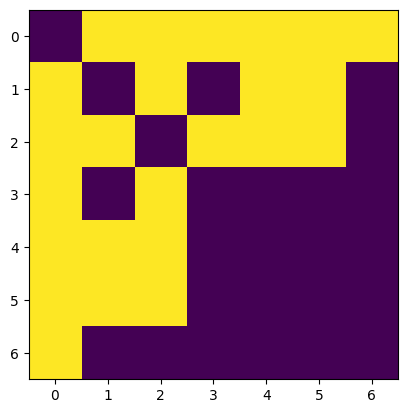

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(est_adj)

In [ ]:
# Con flechas
nodes = estimated_model.nodes()
est_adj = nx.to_numpy_array(
        estimated_model.to_directed(), nodelist=nodes, weight=None
    )

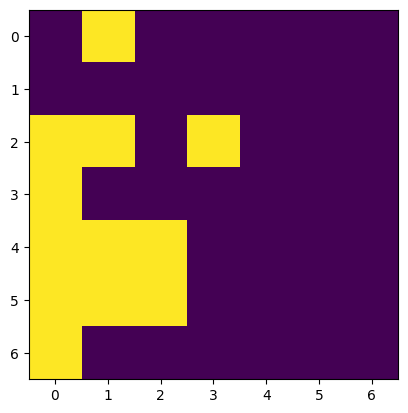

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(est_adj)

In [ ]:
!apt install libgraphviz-dev
!pip install pygraphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libgail-common libgail18 libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  librsvg2-common libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libgail-common libgail18 libgraphviz-dev libgtk2.0-0 libgtk2.0-bin libgtk2.0-common
  libgvc6-plugins-gtk librsvg2-common libxdot4
0 upgraded, 9 newly installed, 0 to remove and 45 not upgraded.
Need to get 2,434 kB of archives.
After this operation, 7,694 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libgtk2.0-common all 2.24.33-2ubuntu2.1 [125 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libgtk2.0-0 amd64 2.24.33-2ubuntu2.1 [2,038 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libgail18 amd64 2.24.33-2ubuntu2.1 [15.9 kB]
Get:4 http://archive.ubun

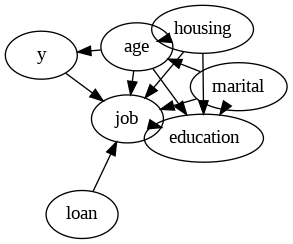

In [ ]:
from IPython.display import Image
import pygraphviz

# Visualize the network
viz = estimated_model.to_graphviz()
viz.draw('estimated_model.png', prog='neato')
Image('estimated_model.png')